In [1]:
import requests
from PIL import Image
from io import BytesIO
from IPython.display import Image as IPImage, display, Audio
import re


In [2]:
# API Key
API_KEY = 'PjLF3G_4MPLjaueSnNnNqzp76XRGEQZI7MGEJzbzArc'

# URLs for the audio files (replace with your own URLs)
correct_sound_url = 'E:\SIH\mixkit-retro-game-notification-212.wav'
wrong_sound_url = 'E:\SIH\mixkit-arcade-retro-game-over-213.wav'


<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Asus\AppData\Local\Temp\ipykernel_17684\3653789023.py:5: SyntaxWarning: invalid escape sequence '\S'
  correct_sound_url = 'E:\SIH\mixkit-retro-game-notification-212.wav'
C:\Users\Asus\AppData\Local\Temp\ipykernel_17684\3653789023.py:6: SyntaxWarning: invalid escape sequence '\S'
  wrong_sound_url = 'E:\SIH\mixkit-arcade-retro-game-over-213.wav'


In [3]:
def fetch_random_image():
    url = 'https://api.unsplash.com/photos/random'
    params = {'client_id': API_KEY, 'count': 1}
    response = requests.get(url, params=params)
    data = response.json()
    
    image_url = data[0]['urls']['regular']
    description = data[0]['alt_description'] or 'No description available'
    
    return image_url, description


In [4]:
def play_sound(url):
    display(Audio(url, autoplay=True))


In [5]:
def is_guess_related(guess, description):
    # Convert both guess and description to lowercase for case-insensitive comparison
    guess = guess.lower()
    description = description.lower()
    
    # Split description into words
    description_words = re.findall(r'\b\w+\b', description)
    
    # Check if guess is a substring of any word in the description
    for word in description_words:
        if word in guess:
            return True
    return False


In [6]:
def show_image_and_ask(image_url, correct_description):
    display(IPImage(url=image_url))
    
    guess = input("What object or thing is in this image? ").strip()
    
    if is_guess_related(guess, correct_description):
        print("Correct! Well done.")
        play_sound(correct_sound_url)
        return True
    else:
        print(f"Game Over! The correct answer was: {correct_description}.")
        play_sound(wrong_sound_url)
        return False


In [7]:
def play_image_recognition_game():
    score = 0  # Initialize the score
    print("Welcome to the Image Recognition Game!")
    print("Type 'quit' to exit the game.")
    
    while True:
        image_url, description = fetch_random_image()
        if show_image_and_ask(image_url, description):
            score += 1
            print(f"Your current score is: {score}")
        else:
            print(f"Final Score: {score}")
            break


E:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8817 - loss: 0.4230 - val_accuracy: 0.9648 - val_loss: 0.1223
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9668 - loss: 0.1085 - val_accuracy: 0.9671 - val_loss: 0.1054
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9785 - loss: 0.0679 - val_accuracy: 0.9708 - val_loss: 0.0919
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9840 - loss: 0.0492 - val_accuracy: 0.9746 - val_loss: 0.0858
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9868 - loss: 0.0397 - val_accuracy: 0.9772 - val_loss: 0.0737
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9898 - loss: 0.0318 - val_accuracy: 0.9766 - val_loss: 0.0804
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9915 - loss: 0.0264 - val_accuracy: 0.9776 - val_loss: 0.0832
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9926 - loss: 0.0203 -

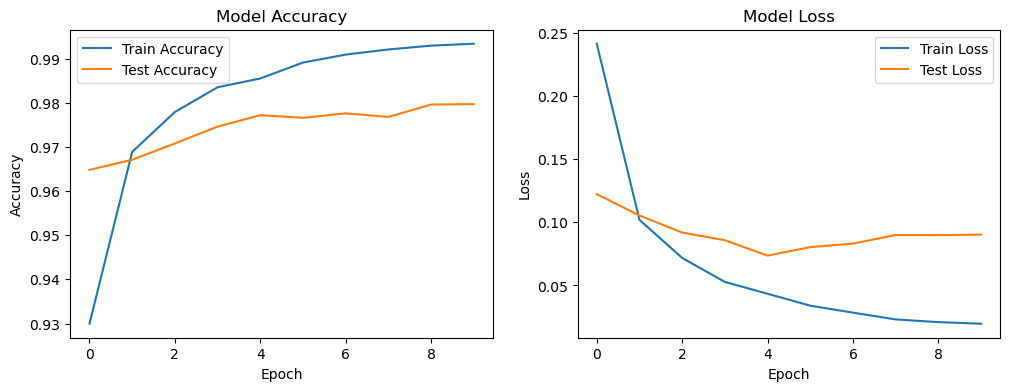

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


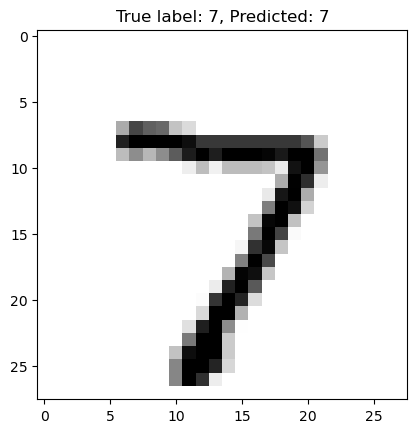

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist

# 1. Load and Preprocess the MNIST Dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize the images to the range [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten the 28x28 images into vectors of size 784 (28*28)
train_images = train_images.reshape((train_images.shape[0], 28 * 28))
test_images = test_images.reshape((test_images.shape[0], 28 * 28))

# 2. Build the Neural Network Model
model = Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# 3. Train the Model
history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

# 4. Evaluate the Model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"\nTest accuracy: {test_acc:.4f}")

# 5. Plot Training & Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 6. Make Predictions
predictions = model.predict(test_images)

# Display first test image with true label and predicted label
plt.imshow(test_images[0].reshape(28, 28), cmap=plt.cm.binary)
plt.title(f"True label: {test_labels[0]}, Predicted: {np.argmax(predictions[0])}")
plt.show()

# 7. Save the Model (Optional)
model.save('mnist_model.h5')


In [2]:
a=2
print(a)

2


In [3]:
type(a)

int

In [4]:
len(a)

TypeError: object of type 'int' has no len()

In [5]:
b=[1,2,"ai',"ml"]
print(b)   

SyntaxError: unterminated string literal (detected at line 1) (3209933915.py, line 1)

In [6]:
b=(1,2,3)
print(b)

(1, 2, 3)


In [7]:
type(b)

tuple

In [8]:
string1 = "this is my python string"
print(string1)

this is my python string


In [9]:
type(string1)

str

In [10]:
string1.capitalize()

'This is my python string'

In [11]:
string1.lower()

'this is my python string'

In [12]:
string1.upper()

'THIS IS MY PYTHON STRING'

In [13]:
type(string1)

str

In [14]:
import numpy as np
arr1 = np.array([1,2,3,4])
arr1

array([1, 2, 3, 4])

In [15]:
type(arr1)

numpy.ndarray

In [16]:
arr1.dtype

dtype('int32')

In [17]:
arr1.argmax()

3

In [18]:
arr1.argmin()

0

In [19]:
len(arr1)

4

In [20]:
arr1.dtype()

TypeError: 'numpy.dtypes.Int32DType' object is not callable

In [21]:
arr1.dtype

dtype('int32')

In [22]:
import numpy as np
import pandas as pd

In [23]:
#import pandas as pd

# Create a DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 40],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston']
}

df = pd.DataFrame(data)

# 1. Access the 'Name' column
print("Names:")
print(df['Name'])

# 2. Filter rows where Age > 30
print("\nFiltered by Age > 30:")
filtered_df = df[df['Age'] > 30]
print(filtered_df)

# 3. Add a new column 'Age Group'
df['Age Group'] = df['Age'].apply(lambda x: 'Young' if x < 30 else 'Old')
print("\nDataFrame with 'Age Group':")
print(df)

# 4. Group by 'City' and calculate mean 'Age'
print("\nMean Age by City:")
grouped_df = df.groupby('City')['Age'].mean()
print(grouped_df)

# 5. Sort by 'Age'
print("\nDataFrame sorted by Age:")
sorted_df = df.sort_values(by='Age', ascending=False)
print(sorted_df)


Names:
0      Alice
1        Bob
2    Charlie
3      David
Name: Name, dtype: object

Filtered by Age > 30:
      Name  Age     City
2  Charlie   35  Chicago
3    David   40  Houston

DataFrame with 'Age Group':
      Name  Age         City Age Group
0    Alice   25     New York     Young
1      Bob   30  Los Angeles       Old
2  Charlie   35      Chicago       Old
3    David   40      Houston       Old

Mean Age by City:
City
Chicago        35.0
Houston        40.0
Los Angeles    30.0
New York       25.0
Name: Age, dtype: float64

DataFrame sorted by Age:
      Name  Age         City Age Group
3    David   40      Houston       Old
2  Charlie   35      Chicago       Old
1      Bob   30  Los Angeles       Old
0    Alice   25     New York     Young


In [24]:
import pandas as pd
df= pd.read_csv('Sample.csv')
print(df)

FileNotFoundError: [Errno 2] No such file or directory: 'Sample.csv'

In [31]:
import pandas as pd
data = {
    'Name':['Vansh','Mayank'],
    'Age': [24,26],
    'City':['England','New Delhi']
}
df = pd.DataFrame(data)
df

    

,Name,Age,City
0,Vansh,24,England
1,Mayank,26,New Delhi


In [32]:
type(df)

pandas.core.frame.DataFrame

In [33]:
len(df)

2

In [34]:
df.head()

,Name,Age,City
0,Vansh,24,England
1,Mayank,26,New Delhi


In [35]:
df.isnull().sum()

Name    0
Age     0
City    0
dtype: int64

In [37]:
df.size

6

In [38]:
df.shape

(2, 3)

In [39]:
type(df)

pandas.core.frame.DataFrame